<a href="https://colab.research.google.com/github/Pacozabala/CSCI199.X-workbench/blob/main/data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Training stats

In [ ]:
bow_df = pd.read_csv("epoch_logs_bow.csv")
fewshot_df = pd.read_csv("epoch_logs_fewshot.csv")
zeroshot_df = pd.read_csv("epoch_logs_zeroshot.csv")

## General performance

In [ ]:
# Store in dict for easier looping
models = {
    "BoW": bow_df,
    "ZeroShot": zeroshot_df,
    "FewShot": fewshot_df
}

def get_final_epoch_stats(df):
    final = df.sort_values("epoch").groupby("fold").tail(1)
    return final

rows = []

for name, df in models.items():
    final = get_final_epoch_stats(df)

    row = {
        "Model": name,
        "Found Macro F1": f"{final['found_macro'].mean():.4f} ± {final['found_macro'].std():.2f}",
        "Found Micro F1": f"{final['found_micro'].mean():.4f} ± {final['found_micro'].std():.2f}",
        "Pol Macro F1": f"{final['pol_macro_mean'].mean():.4f} ± {final['pol_macro_mean'].std():.2f}",
        "Pol Micro F1": f"{final['pol_micro_mean'].mean():.4f} ± {final['pol_micro_mean'].std():.2f}",
    }

    rows.append(row)

general_df = pd.DataFrame(rows)
general_df

NameError: name 'bow_df' is not defined

In [ ]:
print(general_df.to_latex(index=False, escape=False,
                          caption="General Performance per Method",
                          label="tab:general_performance"))

NameError: name 'general_df' is not defined

## Best per fold

In [ ]:
def get_best_per_fold(df):
    idx = df.groupby("fold")["pol_macro_mean"].idxmax()
    return df.loc[idx]

rows = []

for name, df in models.items():
    best = get_best_per_fold(df)

    row = {
        "Model": name,
        "Best Epoch": f"{best['epoch'].mean():.2f}",
        "Found Macro F1": f"{best['found_macro'].mean():.4f}",
        "Pol Macro F1": f"{best['pol_macro_mean'].mean():.4f}",
        "Pol Micro F1": f"{best['pol_micro_mean'].mean():.4f}",
    }

    rows.append(row)

best_df = pd.DataFrame(rows)
best_df

,Model,Best Epoch,Found Macro F1,Pol Macro F1,Pol Micro F1
0,BoW,3.60,0.6578,0.2429,0.3085
1,ZeroShot,2.80,0.6696,0.2721,0.4201
2,FewShot,4.60,0.6629,0.2863,0.3562


In [ ]:
print(best_df.to_latex(index=False, escape=False,
                       caption="Best Perfomance per Method",
                       label="tab:best_performance"))

\begin{table}
\caption{Best Perfomance per Method}
\label{tab:best_performance}
\begin{tabular}{lllll}
\toprule
Model & Best Epoch & Found Macro F1 & Pol Macro F1 & Pol Micro F1 \\
\midrule
BoW & 3.60 & 0.6578 & 0.2429 & 0.3085 \\
ZeroShot & 2.80 & 0.6696 & 0.2721 & 0.4201 \\
FewShot & 4.60 & 0.6629 & 0.2863 & 0.3562 \\
\bottomrule
\end{tabular}
\end{table}



## Training Loss

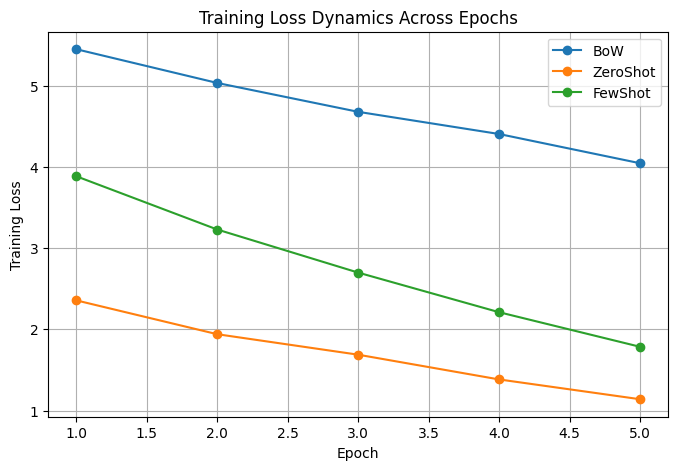

In [ ]:
# -----------------------------
# Compute average loss per epoch
# -----------------------------
loss_dfs = {}

for name, df in models.items():
    loss_dfs[name] = (
        df.groupby("epoch")["train_loss"]
        .mean()
        .reset_index()
        .sort_values("epoch")
    )

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))

for name, loss_df in loss_dfs.items():
    plt.plot(
        loss_df["epoch"],
        loss_df["train_loss"],
        marker="o",
        label=name
    )

plt.title("Training Loss Dynamics Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

# -----------------------------
# Save figure
# -----------------------------
import os

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/training_loss_dynamics.png", dpi=300, bbox_inches="tight")

plt.show()

## Foundation and Polarity across epochs

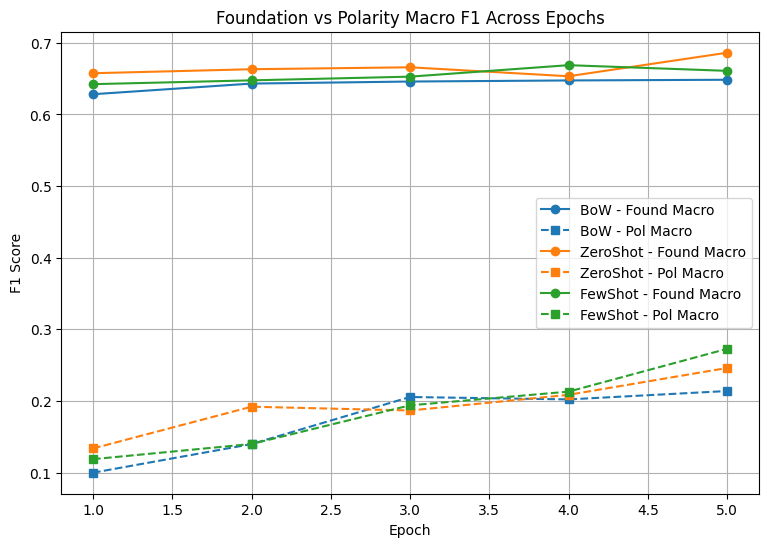

In [ ]:
import matplotlib.pyplot as plt
import os

# -----------------------------
# Aggregate per epoch (mean across folds)
# -----------------------------
def get_epoch_means(df):
    return (
        df.groupby("epoch")[["found_macro", "pol_macro_mean"]]
        .mean()
        .reset_index()
        .sort_values("epoch")
    )

epoch_means = {
    "BoW": get_epoch_means(bow_df),
    "ZeroShot": get_epoch_means(zeroshot_df),
    "FewShot": get_epoch_means(fewshot_df)
}

# -----------------------------
# Define one color per model
# -----------------------------
colors = {
    "BoW": "tab:blue",
    "ZeroShot": "tab:orange",
    "FewShot": "tab:green"
}

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9, 6))

for name, df in epoch_means.items():
    color = colors[name]

    # Foundation Macro (solid line)
    plt.plot(
        df["epoch"],
        df["found_macro"],
        linestyle="-",
        marker="o",
        color=color,
        label=f"{name} - Found Macro"
    )

    # Polarity Macro (dashed line)
    plt.plot(
        df["epoch"],
        df["pol_macro_mean"],
        linestyle="--",
        marker="s",
        color=color,
        label=f"{name} - Pol Macro"
    )

plt.title("Foundation vs Polarity Macro F1 Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)

# -----------------------------
# Save
# -----------------------------
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/found_vs_pol_dynamics.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
pd.DataFrame(epoch_means['FewShot'])

,epoch,found_macro,pol_macro_mean
0,1,0.642336,0.118801
1,2,0.647655,0.140000
2,3,0.652823,0.193978
3,4,0.668845,0.213094
4,5,0.660935,0.272828


In [ ]:
pd.DataFrame(epoch_means['ZeroShot'])

,epoch,found_macro,pol_macro_mean
0,1,0.657594,0.133773
1,2,0.663193,0.192041
2,3,0.665879,0.186763
3,4,0.653402,0.208627
4,5,0.686231,0.246130


## Polarity

In [ ]:
foundations = ["authority", "fairness", "harm", "ingroup", "purity"]

best_per_model = {
    name: get_best_per_fold(df)
    for name, df in models.items()
}

# --- MACRO TABLE ---
macro_rows = []

for f in foundations:
    row = {"Foundation": f}

    for name, best_df in best_per_model.items():
        row[name] = best_df[f"pol_macro_{f}"].mean()

    macro_rows.append(row)

foundation_macro_df = pd.DataFrame(macro_rows)


# --- MICRO TABLE ---
micro_rows = []

for f in foundations:
    row = {"Foundation": f}

    for name, best_df in best_per_model.items():
        row[name] = best_df[f"pol_micro_{f}"].mean()

    micro_rows.append(row)

foundation_micro_df = pd.DataFrame(micro_rows)

In [ ]:
print(foundation_macro_df.to_latex(index=False, escape=False, float_format="%.4f",
                                   caption="Polarity Macro F1 per Model Variant",
                                   label="tab:polarity_macro"))

\begin{table}
\caption{Polarity Macro F1 per Model Variant}
\label{tab:polarity_macro}
\begin{tabular}{lrrr}
\toprule
Foundation & BoW & ZeroShot & FewShot \\
\midrule
authority & 0.1825 & 0.5563 & 0.4134 \\
fairness & 0.3367 & 0.2694 & 0.3319 \\
harm & 0.3537 & 0.2919 & 0.3638 \\
ingroup & 0.2948 & 0.0859 & 0.2392 \\
purity & 0.0469 & 0.1571 & 0.0833 \\
\bottomrule
\end{tabular}
\end{table}



# Helper Functions

## Normalized Foundations

In [6]:
import json
import pandas as pd

def load_foundation_distribution_table(json_path, normalize=True, round_to=2):
    """
    Creates a foundation distribution comparison table across models.

    Parameters:
    - json_path (str): path to JSON file
    - normalize (bool): if True, returns percentages; else raw counts
    - round_to (int): decimal rounding for display

    Returns:
    - pd.DataFrame: comparison table (models x foundations)
    """

    # =========================
    # Load JSON
    # =========================
    with open(json_path, "r") as f:
        data = json.load(f)

    # =========================
    # Get all foundations
    # =========================
    all_foundations = sorted(
        set(
            f
            for model in data.values()
            for f in model["foundation_frequencies"].keys()
        )
    )

    # =========================
    # Build table
    # =========================
    rows = []

    for model_name, model_data in data.items():
        freqs = model_data["foundation_frequencies"]

        if normalize:
            total = sum(freqs.values())
            values = {k: (v / total * 100 if total > 0 else 0) for k, v in freqs.items()}
        else:
            values = freqs

        row = {"Model": model_name}

        for f in all_foundations:
            row[f] = values.get(f, 0.0)

        rows.append(row)

    df = pd.DataFrame(rows)

    # =========================
    # Reorder columns
    # =========================
    df = df[["Model"] + all_foundations]

    # =========================
    # Optional rounding
    # =========================
    if round_to is not None:
        for col in all_foundations:
            df[col] = df[col].round(round_to)

    return df


## Stacked polarity distribution

In [7]:
import json
import matplotlib.pyplot as plt

def plot_polarity_distribution(
    json_path,
    save_path=None,
    figsize_per_model=5,
    show_plot=True
):
    """
    Creates stacked bar charts of polarity distributions per foundation per model.

    Parameters:
    - json_path (str): path to JSON file
    - save_path (str or None): if set, saves figure to this path
    - figsize_per_model (int): width scaling per subplot
    - show_plot (bool): whether to display plot

    Returns:
    - fig, axes
    """

    # =========================
    # Load JSON
    # =========================
    with open(json_path, "r") as f:
        data = json.load(f)

    models = list(data.keys())

    # =========================
    # Collect all foundations
    # =========================
    foundations = sorted(
        set(
            p.split(".")[0]
            for m in data.values()
            for p in m["foundation_polarity_frequencies"].keys()
        )
    )

    polarity_order = ["virtue", "vice", "neutral"]

    # =========================
    # Create figure
    # =========================
    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(figsize_per_model * len(models), 5),
        sharey=True
    )

    if len(models) == 1:
        axes = [axes]

    # =========================
    # Plot per model
    # =========================
    for ax, (model_name, model_data) in zip(axes, data.items()):

        freqs = model_data["foundation_polarity_frequencies"]
        total = sum(freqs.values())

        # normalize
        norm = {
            k: (v / total * 100 if total > 0 else 0)
            for k, v in freqs.items()
        }

        bottom = {f: 0 for f in foundations}

        for polarity in polarity_order:
            values = []

            for f in foundations:
                key = f"{f}.{polarity}"
                values.append(norm.get(key, 0.0))

            ax.bar(
                foundations,
                values,
                bottom=[bottom[f] for f in foundations],
                label=polarity
            )

            # update stacking base
            for f, v in zip(foundations, values):
                bottom[f] += v

        ax.set_title(model_name)
        ax.set_xlabel("Foundation")
        ax.set_ylabel("Percentage (%)")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title="Polarity")

    plt.tight_layout()

    # =========================
    # Save figure
    # =========================
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    # =========================
    # Show
    # =========================
    if show_plot:
        plt.show()

    return fig, axes


## Inference comparison per model

In [10]:
def compare_model_across_datasets(
    json_path_1,
    json_path_2,
    model_name,
    dataset_labels=("Dataset 1", "Dataset 2"),
    save_path=None,
    figsize=(12, 5),
    show_plot=True
):
    """
    Compare polarity distributions for a single model across two datasets.

    Parameters:
    - json_path_1, json_path_2 (str): paths to JSON files
    - model_name (str): e.g., "bow", "llama_fewshot"
    - dataset_labels (tuple): titles for the two subplots
    - save_path (str or None): if set, saves figure
    - figsize (tuple): figure size
    - show_plot (bool): display plot

    Returns:
    - fig, axes
    """

    # =========================
    # Load JSONs
    # =========================
    with open(json_path_1, "r") as f:
        data1 = json.load(f)

    with open(json_path_2, "r") as f:
        data2 = json.load(f)

    if model_name not in data1 or model_name not in data2:
        raise ValueError(f"Model '{model_name}' not found in both JSON files.")

    model1 = data1[model_name]
    model2 = data2[model_name]

    # =========================
    # Collect all foundations across both datasets
    # =========================
    def get_foundations(model_dict):
        return set(p.split(".")[0] for p in model_dict["foundation_polarity_frequencies"].keys())

    foundations = sorted(get_foundations(model1) | get_foundations(model2))

    polarity_order = ["virtue", "vice", "neutral"]

    # =========================
    # Normalize helper
    # =========================
    def normalize(freqs):
        total = sum(freqs.values())
        return {k: (v / total * 100 if total > 0 else 0) for k, v in freqs.items()}

    norm1 = normalize(model1["foundation_polarity_frequencies"])
    norm2 = normalize(model2["foundation_polarity_frequencies"])

    # =========================
    # Plot
    # =========================
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for ax, norm_data, title in zip(
        axes,
        [norm1, norm2],
        dataset_labels
    ):
        bottom = {f: 0 for f in foundations}

        for polarity in polarity_order:
            values = []

            for f in foundations:
                key = f"{f}.{polarity}"
                values.append(norm_data.get(key, 0.0))

            ax.bar(
                foundations,
                values,
                bottom=[bottom[f] for f in foundations],
                label=polarity
            )

            # update stacking
            for f, v in zip(foundations, values):
                bottom[f] += v

        ax.set_title(f"{model_name} — {title}")
        ax.set_xlabel("Foundation")
        ax.set_ylabel("Percentage (%)")
        ax.tick_params(axis="x", rotation=45)

    # Only show legend once (right side)
    axes[1].legend(title="Polarity")

    plt.tight_layout()

    # =========================
    # Save
    # =========================
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    if show_plot:
        plt.show()

    return fig, axes

# Model Comparison

In [8]:
ip_json_path = "/content/stats_israel-palestine.json"
ii_json_path = "/content/stats_israel-iran.json"

Saved figure to: /content/bow_dataset_comparison.png


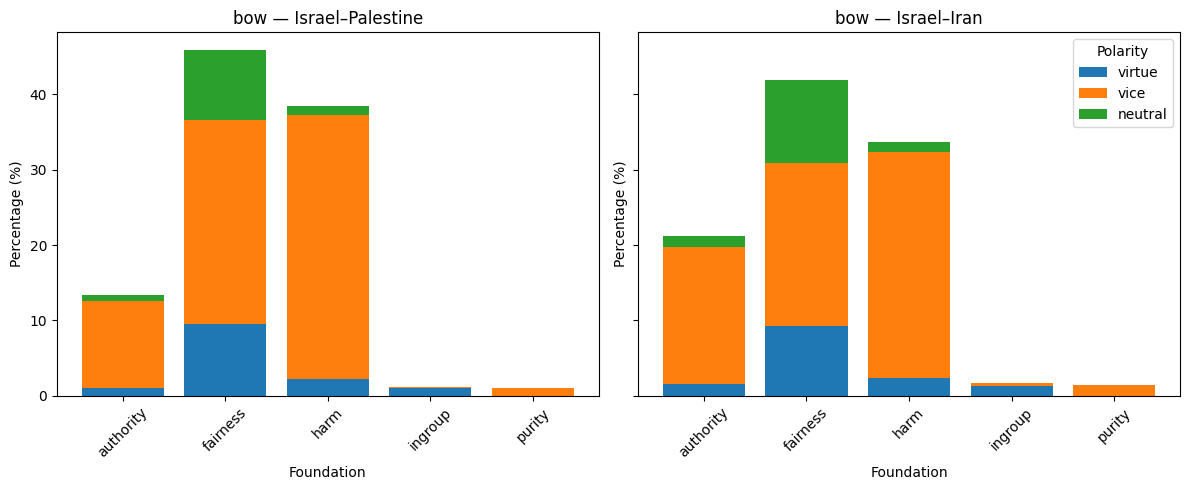

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'bow — Israel–Palestine'}, xlabel='Foundation', ylabel='Percentage (%)'>,
        <Axes: title={'center': 'bow — Israel–Iran'}, xlabel='Foundation', ylabel='Percentage (%)'>],
       dtype=object))

In [12]:
compare_model_across_datasets(
    ip_json_path,
    ii_json_path,
    model_name="bow",
    dataset_labels=("Israel–Palestine", "Israel–Iran"),
    save_path="/content/bow_dataset_comparison.png"
)

Saved figure to: /content/zeroshot_dataset_comparison.png


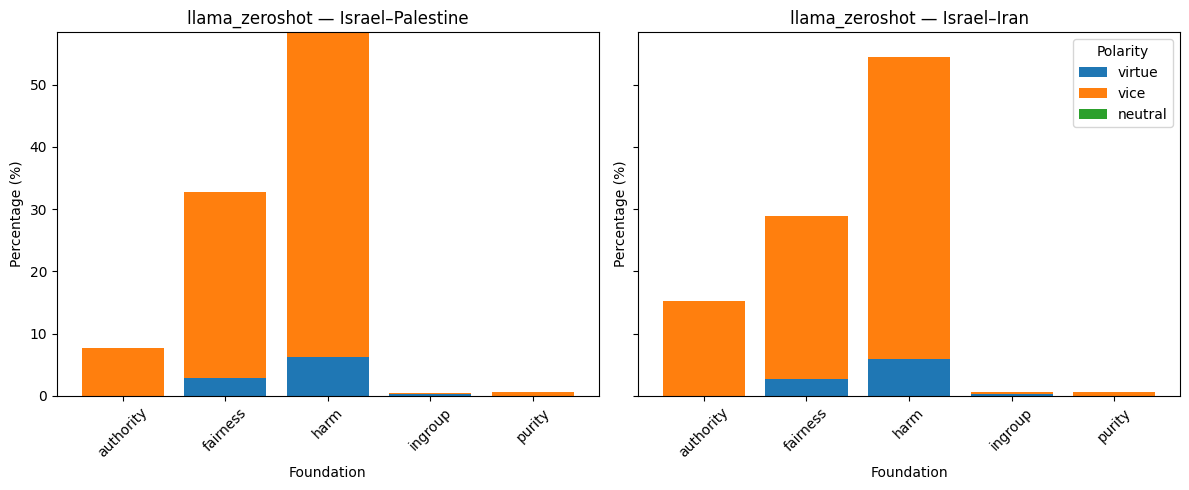

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'llama_zeroshot — Israel–Palestine'}, xlabel='Foundation', ylabel='Percentage (%)'>,
        <Axes: title={'center': 'llama_zeroshot — Israel–Iran'}, xlabel='Foundation', ylabel='Percentage (%)'>],
       dtype=object))

In [13]:
compare_model_across_datasets(
    ip_json_path,
    ii_json_path,
    model_name="llama_zeroshot",
    dataset_labels=("Israel–Palestine", "Israel–Iran"),
    save_path="/content/zeroshot_dataset_comparison.png"
)

Saved figure to: /content/fewshot_dataset_comparison.png


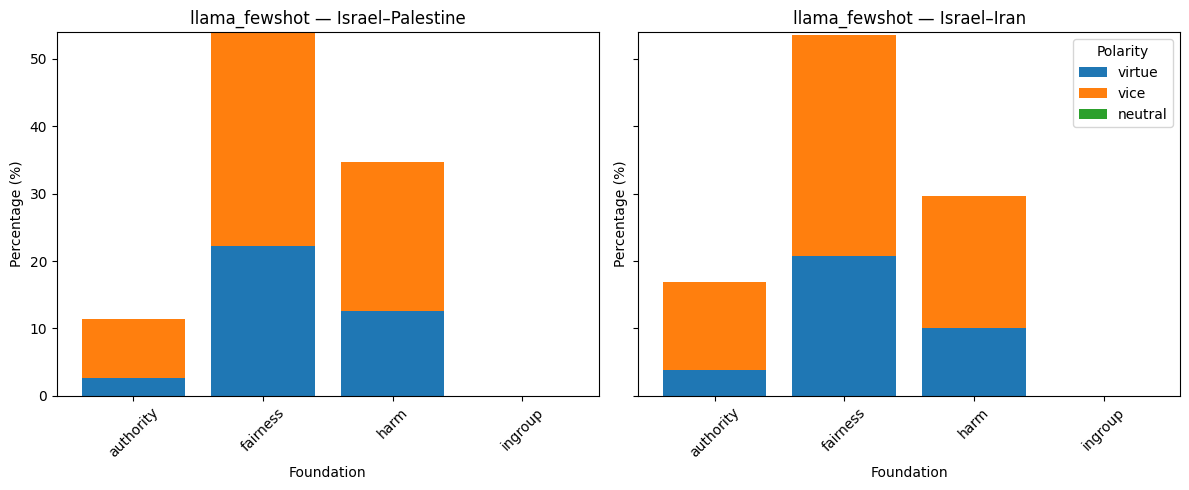

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'llama_fewshot — Israel–Palestine'}, xlabel='Foundation', ylabel='Percentage (%)'>,
        <Axes: title={'center': 'llama_fewshot — Israel–Iran'}, xlabel='Foundation', ylabel='Percentage (%)'>],
       dtype=object))

In [15]:
compare_model_across_datasets(
    ip_json_path,
    ii_json_path,
    model_name="llama_fewshot",
    dataset_labels=("Israel–Palestine", "Israel–Iran"),
    save_path="/content/fewshot_dataset_comparison.png"
)

# Israel-Palestine

In [ ]:

# =========================
# Load JSON file
# =========================
json_path = "/content/stats_israel-palestine.json"

df = load_foundation_distribution_table(json_path)
df = df.round(4)
df

,Model,authority,fairness,harm,ingroup,purity
0,bow,13.32,45.90,38.48,1.24,1.06
1,llama_fewshot,11.41,53.90,34.66,0.03,0.00
2,llama_zeroshot,7.66,32.84,58.42,0.53,0.56


In [ ]:
print(df.to_latex(index=False, escape=False, bold_rows=True,
                          caption="Normalized Foundation Distribution (Israel-Palestine)",
                          label="tab:ip_normalized_found"))

\begin{table}
\caption{Normalized Foundation Distribution (Israel-Palestine)}
\label{tab:ip_normalized_found}
\begin{tabular}{lrrrrr}
\toprule
Model & authority & fairness & harm & ingroup & purity \\
\midrule
bow & 13.320000 & 45.900000 & 38.480000 & 1.240000 & 1.060000 \\
llama_fewshot & 11.410000 & 53.900000 & 34.660000 & 0.030000 & 0.000000 \\
llama_zeroshot & 7.660000 & 32.840000 & 58.420000 & 0.530000 & 0.560000 \\
\bottomrule
\end{tabular}
\end{table}



Saved figure to: /content/ip_polarity_plot.png


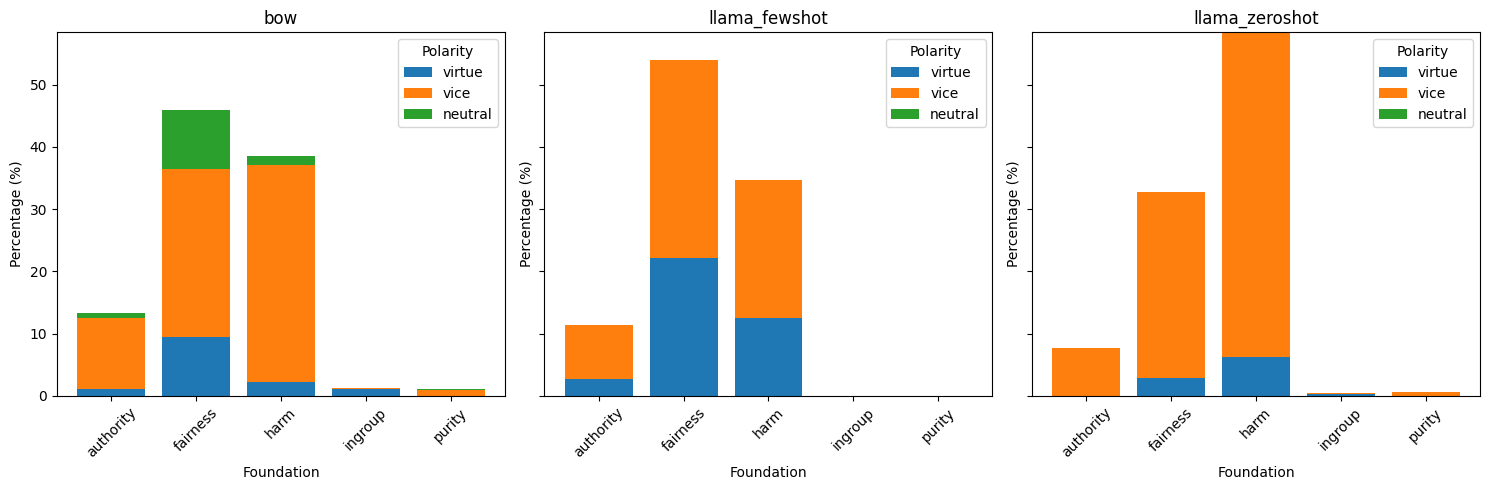

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'bow'}, xlabel='Foundation', ylabel='Percentage (%)'>,
        <Axes: title={'center': 'llama_fewshot'}, xlabel='Foundation', ylabel='Percentage (%)'>,
        <Axes: title={'center': 'llama_zeroshot'}, xlabel='Foundation', ylabel='Percentage (%)'>],
       dtype=object))

In [ ]:
json_path = "/content/stats_israel-palestine.json"

plot_polarity_distribution(
    json_path,
    save_path="/content/ip_polarity_plot.png"
)

# Israel-Iran

In [ ]:
json_path="/content/stats_israel-iran.json"

df = load_foundation_distribution_table(json_path)
df

,Model,authority,fairness,harm,ingroup,purity
0,bow,21.15,41.87,33.72,1.75,1.51
1,llama_fewshot,16.91,53.48,29.57,0.04,0.00
2,llama_zeroshot,15.25,28.83,54.53,0.67,0.70


In [ ]:
print(df.to_latex(index=False, escape=False, bold_rows=True,
                  caption="Normalized Foundation Distribution (Israel-Iran)",
                  label="tab:ii_normalized_found"))

\begin{table}
\caption{Normalized Foundation Distribution (Israel-Iran)}
\label{tab:ii_normalized_found}
\begin{tabular}{lrrrrr}
\toprule
Model & authority & fairness & harm & ingroup & purity \\
\midrule
bow & 21.150000 & 41.870000 & 33.720000 & 1.750000 & 1.510000 \\
llama_fewshot & 16.910000 & 53.480000 & 29.570000 & 0.040000 & 0.000000 \\
llama_zeroshot & 15.250000 & 28.830000 & 54.530000 & 0.670000 & 0.700000 \\
\bottomrule
\end{tabular}
\end{table}



Saved figure to: /content/ii_polarity_plot.png


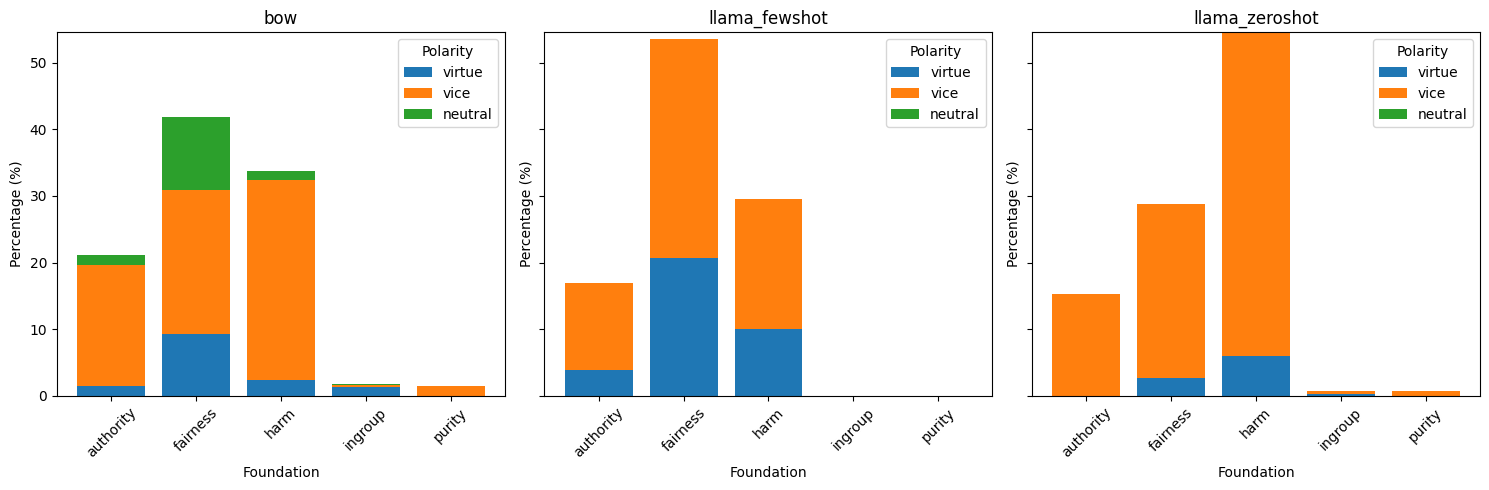

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'bow'}, xlabel='Foundation', ylabel='Percentage (%)'>,
        <Axes: title={'center': 'llama_fewshot'}, xlabel='Foundation', ylabel='Percentage (%)'>,
        <Axes: title={'center': 'llama_zeroshot'}, xlabel='Foundation', ylabel='Percentage (%)'>],
       dtype=object))

In [ ]:
plot_polarity_distribution(
    json_path,
    save_path="/content/ii_polarity_plot.png"
)

# Presentation Figures

## MFRC Label Distribution

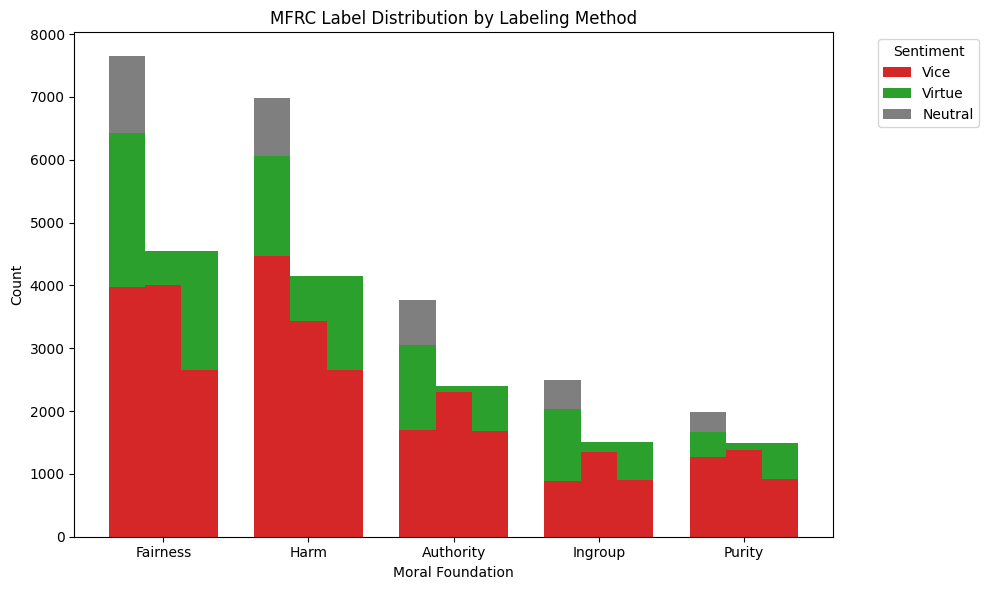

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data (from your table)
# -----------------------------
foundations = ["Fairness", "Harm", "Authority", "Ingroup", "Purity"]

data = {
    "BoW": {
        "Vice":    [3982, 4465, 1698,  890, 1263],
        "Virtue":  [2437, 1588, 1359, 1146,  406],
        "Neutral": [1226,  932,  708,  460,  314],
    },
    "Zero-shot": {
        "Vice":    [4013, 3435, 2298, 1342, 1380],
        "Virtue":  [ 541,  713,   96,  170,  112],
        "Neutral": [   0,    0,    0,    0,    0],
    },
    "Few-shot": {
        "Vice":    [2651, 2656, 1687,  904,  914],
        "Virtue":  [1903, 1492,  707,  608,  578],
        "Neutral": [   0,    0,    0,    0,    0],
    }
}

methods = list(data.keys())
sentiments = ["Vice", "Virtue", "Neutral"]

# -----------------------------
# Plot setup
# -----------------------------
x = np.arange(len(foundations))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "Vice": "#d62728",    # red
    "Virtue": "#2ca02c",  # green
    "Neutral": "#7f7f7f"  # gray
}

# -----------------------------
# Plot grouped stacked bars
# -----------------------------
for i, method in enumerate(methods):
    bottom = np.zeros(len(foundations))

    for sentiment in sentiments:
        values = np.array(data[method][sentiment])

        ax.bar(
            x + (i - 1) * bar_width,
            values,
            bar_width,
            bottom=bottom,
            color=colors[sentiment],   # ✅ consistent color mapping
            label=sentiment if i == 0 else None  # only label once
        )

        bottom += values

# -----------------------------
# Formatting
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(foundations)

ax.set_title("MFRC Label Distribution by Labeling Method")
ax.set_ylabel("Count")
ax.set_xlabel("Moral Foundation")

# Clean legend (only sentiments)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("mfrc_label_distribution", dpi=300, bbox_inches="tight")
plt.show()

## Aggregate Performance

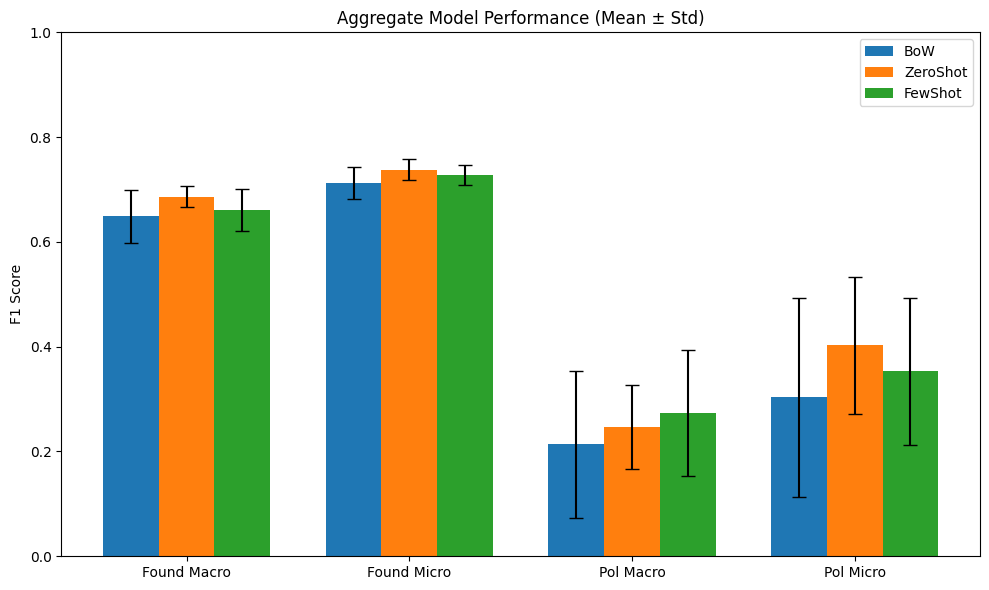

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data
# -----------------------------
metrics = ["Found Macro", "Found Micro", "Pol Macro", "Pol Micro"]

means = {
    "BoW":      [0.6485, 0.7126, 0.2139, 0.3035],
    "ZeroShot": [0.6862, 0.7375, 0.2461, 0.4024],
    "FewShot":  [0.6609, 0.7277, 0.2728, 0.3530],
}

stds = {
    "BoW":      [0.05, 0.03, 0.14, 0.19],
    "ZeroShot": [0.02, 0.02, 0.08, 0.13],
    "FewShot":  [0.04, 0.02, 0.12, 0.14],
}

models = list(means.keys())

# -----------------------------
# Plot setup
# -----------------------------
x = np.arange(len(metrics))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

# -----------------------------
# Plot bars with error bars
# -----------------------------
for i, model in enumerate(models):
    ax.bar(
        x + (i - 1) * bar_width,
        means[model],
        bar_width,
        yerr=stds[model],
        capsize=5,
        label=model
    )

# -----------------------------
# Formatting
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylabel("F1 Score")
ax.set_title("Aggregate Model Performance (Mean ± Std)")

ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()

# -----------------------------
# Save figure
# -----------------------------
plt.savefig("model_summaries.png", dpi=300, bbox_inches="tight")

plt.show()

## Per-head Polarity Performance

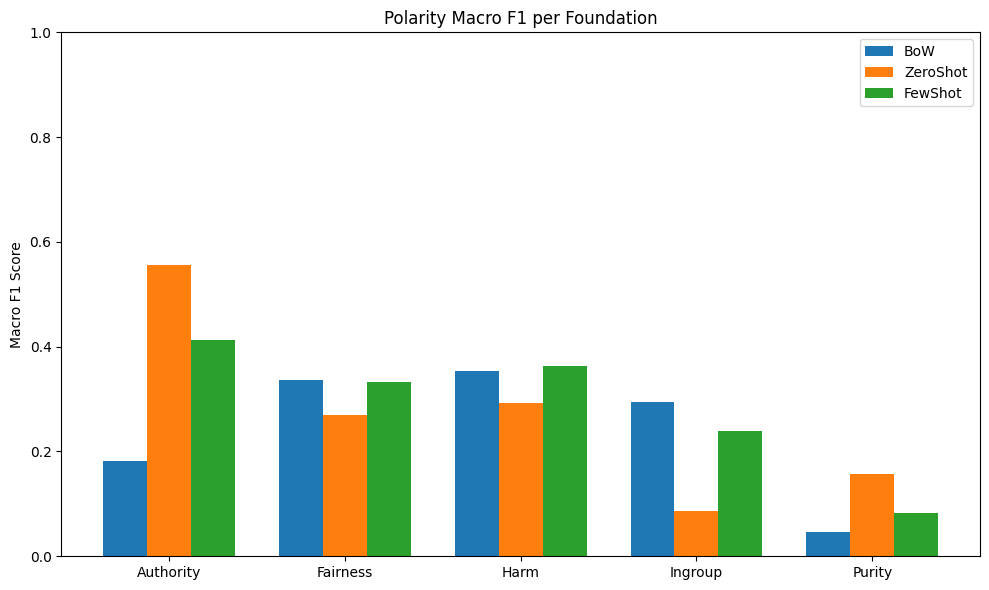

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data
# -----------------------------
foundations = ["Authority", "Fairness", "Harm", "Ingroup", "Purity"]

means = {
    "BoW":      [0.1825, 0.3367, 0.3537, 0.2948, 0.0469],
    "ZeroShot": [0.5563, 0.2694, 0.2919, 0.0859, 0.1571],
    "FewShot":  [0.4134, 0.3319, 0.3638, 0.2392, 0.0833],
}

models = list(means.keys())

# -----------------------------
# Plot setup
# -----------------------------
x = np.arange(len(foundations))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

# -----------------------------
# Plot grouped bars
# -----------------------------
for i, model in enumerate(models):
    ax.bar(
        x + (i - 1) * bar_width,
        means[model],
        bar_width,
        label=model
    )

# -----------------------------
# Formatting
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(foundations)

ax.set_ylabel("Macro F1 Score")
ax.set_title("Polarity Macro F1 per Foundation")

ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()

# -----------------------------
# Save figure
# -----------------------------
plt.savefig("polarity_macro_f1.png", dpi=300, bbox_inches="tight")

plt.show()